In [1]:
using ITensors, ITensorMPS, Plots
using Plots.PlotMeasures
using LinearAlgebra
using HDF5

### Initial Parameters ###

In [2]:
N = 5 #Number of lattice sites per dimension
d = 1 #Number of spatial dimensions
Dim = 10 #Truncated local Hilbert space dimension
a = 1 #Lattice spacing

n_0 = round(Int, ((N-1)/2)) #Index of the point at the center of the lattice (0-based indexing).
dp = 2pi/(N*a) #Discrete change in momentum

mass = 1
m0 = 1 #Basis frequency
l = 0.1; #phi^4 coupling strength

### Field Operator $\phi(\mathbf{x})$ and $\pi(\mathbf{x})$ ###

In [3]:
function a_matrix(D)
    A = zeros(D, D)
    for n in 1:D-1
        A[n, n+1] = sqrt(n)
    end
    return A
end

phi_matrix = D -> (a_matrix(D) + a_matrix(D)')/sqrt(2*m0)
pi_matrix = D -> im*sqrt(m0/2)*(a_matrix(D)' - a_matrix(D))

ITensors.op(::OpName"phi", ::SiteType"Boson", D::Int) = phi_matrix(D)

ITensors.op(::OpName"phi2", ::SiteType"Boson", D::Int) = phi_matrix(D)^2

ITensors.op(::OpName"phi4", ::SiteType"Boson", D::Int) = phi_matrix(D)^4

ITensors.op(::OpName"pi", ::SiteType"Boson", D::Int) = pi_matrix(D)

ITensors.op(::OpName"pi2", ::SiteType"Boson", D::Int) = pi_matrix(D)^2

### Hamiltonian ###

In [4]:
H0 = OpSum() #Non-interacting Hamiltonian OpSum
for x in 1:N
    H0 += a^d/2, "pi2", x
    H0 += a^d * d/a^2, "phi2", x
    if x < N
        H0 -= a^d * 1/a^2, "phi", x, "phi", x+1
    else
        H0 -= a^d * 1/a^2, "phi", x, "phi", 1
    end
    H0 += a^d/2 * mass^2, "phi2", x
end

HInt = OpSum() #Interacting Hamiltonian OpSum
for x in 1:N
    HInt += l/factorial(4) * a^d, "phi4", x
end

H_OS = H0 + HInt #Full Hamiltonian OpSum

sites = siteinds("Boson", N; dim=Dim); #Create ITensor sites

H = MPO(H_OS, sites); #Hamiltonian MPO

### Vacuum State MPS ###

In [5]:
psi0 = random_mps(sites;linkdims=10)
nsweeps = 5
maxdim = [10,20,100,100,200]
cutoff = [1E-10]
energy, vac = dmrg(H,psi0;nsweeps,maxdim,cutoff)

After sweep 1 energy=6.985011997059216  maxlinkdim=10 maxerr=2.60E-02 time=21.856
After sweep 2 energy=4.697602648449039  maxlinkdim=20 maxerr=3.76E-06 time=0.142
After sweep 3 energy=4.2871817428889445  maxlinkdim=61 maxerr=9.16E-11 time=0.887
After sweep 4 energy=4.2166341208268845  maxlinkdim=55 maxerr=9.94E-11 time=0.865
After sweep 5 energy=4.202947617191027  maxlinkdim=49 maxerr=9.12E-11 time=0.454


(4.202947617191027, MPS
[1] ((dim=10|id=759|"Link,l=1"), (dim=10|id=746|"Boson,Site,n=1"))
[2] ((dim=43|id=865|"Link,l=2"), (dim=10|id=595|"Boson,Site,n=2"), (dim=10|id=759|"Link,l=1"))
[3] ((dim=10|id=677|"Boson,Site,n=3"), (dim=49|id=535|"Link,l=3"), (dim=43|id=865|"Link,l=2"))
[4] ((dim=10|id=378|"Boson,Site,n=4"), (dim=10|id=36|"Link,l=4"), (dim=49|id=535|"Link,l=3"))
[5] ((dim=10|id=412|"Boson,Site,n=5"), (dim=10|id=36|"Link,l=4"))
)

### Energy Flux Operator ###

In [6]:
#Make lattice spacing an input parameter that defaults to a=1

#Function for applying the T_{0i}(x,t) operator.
#Params: state to apply T_{0i} on, time of measurement, position of detector (as a tuple)
function T0i(state, t, r; dir=0, nsteps=1, maxdim=200, cutoff=1e-8)
    psi = copy(state)

    #Apply exp(-iHt). (I am using the forward time evolution convention, but 2604.26226 uses the inverse time evolution convention.)
    psi = tdvp(H, -im*t, psi; nsteps=nsteps, maxdim=maxdim, cutoff=cutoff, normalize=true)

    #Apply T_{0i}(x). (Specifically, T_{01}(x) in 1+1d)
    x = r[1] #x-component of the detector's position
    #= if r != 0
        n = r ./ norm(r) #Unit vector in the direction of the detector
    elseif r == 0 && dir != 0
        n = dir ./ norm(dir)
    else
        throw(ArgumentError("dir must be nonzero for r=0"))
    end
    nx = n[1] #x-component of the unit direction vector =#

    T0x_OS = OpSum()
    if x > 0 || (x == 0 && dir > 0)
        T0x_OS += 1/2 * a^(d-2), "phi", (n_0+1) + x, "pi", (n_0+1) + x+1
        T0x_OS -= 1/2 * a^(d-2), "phi", (n_0+1) + x+1, "pi", (n_0+1) + x
    elseif x < 0 || (x == 0 && dir < 0)
        T0x_OS += 1/2 * a^(d-2), "phi", (n_0+1) + x, "pi", (n_0+1) + x-1
        T0x_OS -= 1/2 * a^(d-2), "phi", (n_0+1) + x-1, "pi", (n_0+1) + x
    end

    T0i_MPO = MPO(T0x_OS, sites)
    psi = apply(T0i_MPO, psi)

    #Apply exp(iHt)
    psi = tdvp(H, im*t, psi; nsteps=nsteps, maxdim=maxdim, cutoff=cutoff, normalize=true)

    return psi
end

T0i (generic function with 1 method)

### Check Energy Conservation ###

In [12]:
dir_list = [1, -1]
t_max = 5
dt = 1
t_range = range(0, t_max, step=dt)

#Define the excited state, \phi(0)\ket{\omega}
phi0_OS = OpSum()
phi0_OS += "phi", n_0+1
phi0 = MPO(phi0_OS, sites)

psi = apply(phi0, vac) #Excited state

function CalcEdensOut(t, dir_list)
    s_range = range(0, t, step=dt)
    Edens_list = []
    for dir in dir_list
        Edens = 0
        for s in s_range
            evT = inner(psi, T0i(psi, s, 0, dir=dir))
            Edens += dt*evT
        end
        push!(Edens_list, Edens)
    end
    return sum(Edens_list)
end

H_0_OS = OpSum() #Hamiltonian OpSum at index n_0 (i.e. x=0)
H_0_OS += a^d/2, "pi2", n_0+1
H_0_OS += a^d/2 * mass^2, "phi2", n_0+1
H_0_OS += l/factorial(4) * a^d, "phi4", n_0+1
H_0_OS += a^d * 1/(a^2), "phi2", n_0+1
H_0_OS -= 1/2 * a^d * 1/a^2, "phi", n_0+1, "phi", (n_0+1)+1
H_0_OS -= 1/2 * a^d * 1/a^2, "phi", n_0+1, "phi", (n_0+1)-1
H_n_0 = MPO(H_0_OS , sites)

function CalcEdens0(t; nsteps=1, maxdim=200, cutoff=1e-8)
    psi_t = tdvp(H, -im*t, psi; nsteps=nsteps, maxdim=maxdim, cutoff=cutoff, normalize=true)
    evH = inner(psi_t', H_n_0, psi_t) #/ inner(psi, psi)
    return evH
end

Edens0 = []
EdensTot = []
for t in t_range
    evH = CalcEdens0(t)
    EdensOut = CalcEdensOut(t, dir_list)
    push!(Edens0, evH)
    push!(EdensTot, evH + EdensOut)
end

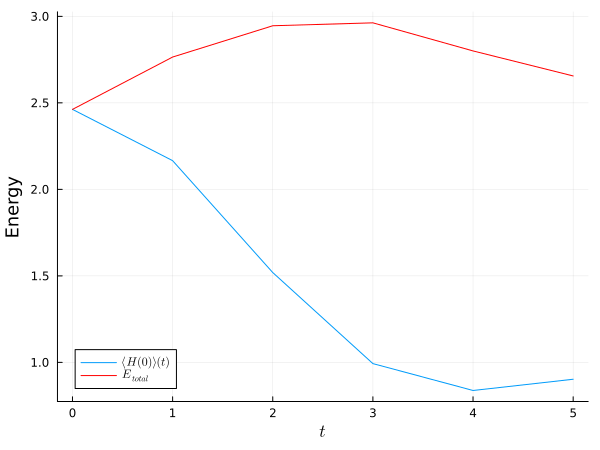

In [16]:
plot(t_range, real(Edens0),
    guidefont=font(12),
    xlabel="\$t\$",
    ylabel="Energy",
    size=(600, 450),
    label="\$⟨{H(0)}⟩(t)\$")
plot!(t_range, real(EdensTot), color="red", label="\$E_{total}\$")

In [17]:
#Expected outgoing energy density
real(Edens0[1].-Edens0)

6-element Vector{Float64}:
 0.0
 0.2964304077088822
 0.9431041099260975
 1.469356382059134
 1.6246922303934208
 1.5596839421727664

In [18]:
#Calculated outgoing energy density
real(EdensTot - Edens0)

6-element Vector{Float64}:
 0.0
 0.599016903356727
 1.4264771157037397
 1.96955213405252
 1.9625326583966825
 1.7528289144615108

In [19]:
#Multiplicative Error
(EdensTot - Edens0) ./ (Edens0[1].-Edens0)

6-element Vector{ComplexF64}:
                NaN + NaN*im
  2.020767396929833 - 3.897514115625698e-8im
  1.512534088962373 - 2.0078054157808729e-7im
 1.3404182661883697 + 2.794414018630375e-7im
 1.2079411852184787 + 6.111823416605453e-7im
 1.1238359689846378 + 4.805957312499005e-7im

### EEC Parameters ###

In [ ]:
#Coordinate position of the detectors (as tuples). (The lattice index is given by (n_0+1) + the ith component)
r1 = 1
r2 = -1
#Measurement time
t1_max = 0.5
t2_max = 0.5
dt = 0.1
t1_range = range(0, t1_max, step=dt)
t2_range = range(0, t2_max, step=dt)

0.0:0.1:0.5

### Compute the EEC ###

In [ ]:
#Define the excited state, \phi(0)\ket{\omega}
phi0_OS = OpSum()
phi0_OS += "phi", n_0+1
phi0 = MPO(phi0_OS, sites)

psi = apply(phi0, vac) #Excited state

#Define the Correlator as a callable function
function C(r1, r2, t1, t2)
    Tpsi = T0i(psi, t2, r2)
    TTpsi = T0i(Tpsi, t1, r1)
    return inner(psi, TTpsi)
end

#"Integrate" the correlators over t1 and t2
function calcEEC(r1, r2)
    EEC = 0
    for t1 in t1_range
        for t2 in t2_range
            EEC += dt^2 * r1^(d-1) * r2^(d-1) * C(r1, r2, t1, t2)
        end
    end
    return EEC
end

EEC = calcEEC(r1, r2)

-0.0021215668191322773 - 2.2310331805485246e-5im

### Compute $\bra{\Omega}\phi^\dagger(0)T_{0x}\phi(0)\ket{\Omega}(t)$ ###

In [ ]:
r=1
t_max = 5
dt = 0.1
t_range = range(0, t_max, step=dt)

expvals = []
for t in t_range
    evT = inner(psi, T0i(psi, t, r))
    push!(expvals, evT)
end

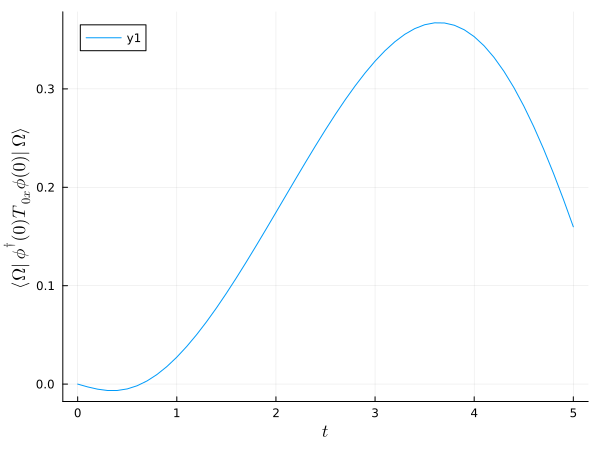

In [ ]:
plot(t_range, real(expvals),
    guidefont=font(12),
    xlabel="\$t\$",
    ylabel="\$\\langle\\Omega|\\phi^{\\dagger}(0)T_{0x}\\phi(0)|{\\Omega}\\rangle\$",
    size=(600, 450)
    )